# Day 10: Vector Store + Similarity Search
Building FAISS index and running "find top-5 candidates" queries

In [1]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sentence_transformers import SentenceTransformer
sys.path.append("../src")
from vector_store import VectorStore

BASE  = Path("../data/processed")
model = SentenceTransformer("all-MiniLM-L6-v2")

store = VectorStore()
store.load(str(BASE))
print(" Vector store ready")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

   Loaded FAISS index: 80 vectors
 Vector store ready


In [2]:
# Query 1: ML role
results = store.search_by_text(
    "Python ML engineer with TensorFlow and deep learning",
    model, top_k=5
)
print("Top 5 for ML role:")
print(results[["rank","name","role","experience_years",
               "availability_pct","similarity_score"]].to_string(index=False))

Top 5 for ML role:
 rank               name        role  experience_years  availability_pct  similarity_score
    1         Arya Shere ML Engineer                10                40            0.7061
    2       Tripti Yadav ML Engineer                 8               100            0.6550
    3 Wriddhish Bhardwaj ML Engineer                 2                80            0.6516
    4   Gayathri Chaudry ML Engineer                 8                80            0.6350
    5      Priya Rastogi ML Engineer                 8               100            0.6320


In [3]:
# Query 2: Backend role
results2 = store.search_by_text(
    "Backend developer with Python FastAPI and PostgreSQL",
    model, top_k=5
)
print("Top 5 for Backend role:")
print(results2[["rank","name","role","experience_years",
                "availability_pct","similarity_score"]].to_string(index=False))

Top 5 for Backend role:
 rank            name        role  experience_years  availability_pct  similarity_score
    1    Isha Kadakia Backend Dev                 8                80            0.6679
    2   Michael Dutta Backend Dev                 1                80            0.6410
    3 Yashica Cherian Backend Dev                 1                60            0.6215
    4      Gagan Sami Backend Dev                 6                60            0.6200
    5     Kabir Soman Backend Dev                 5               100            0.6133


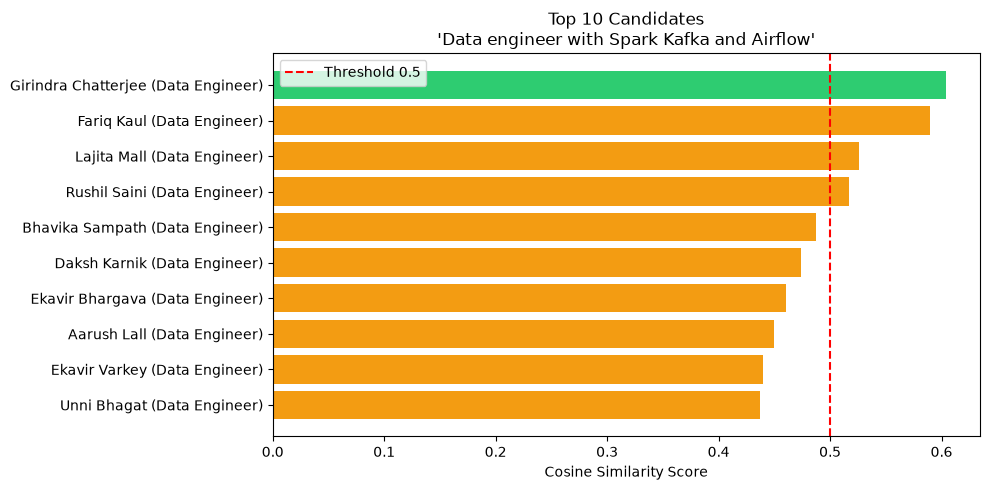

In [4]:
# Visualise similarity scores for a query
query = "Data engineer with Spark Kafka and Airflow"
res   = store.search_by_text(query, model, top_k=10)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if s > 0.6 else "#f39c12" if s > 0.4
          else "#e74c3c" for s in res["similarity_score"]]
bars = ax.barh(
    [f"{r['name']} ({r['role']})" for _, r in res.iterrows()],
    res["similarity_score"], color=colors
)
ax.axvline(x=0.5, color="red", linestyle="--", label="Threshold 0.5")
ax.set_xlabel("Cosine Similarity Score")
ax.set_title(f"Top 10 Candidates\n'{query}'", fontsize=12)
ax.legend(); ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/processed/day10_search_results.png", dpi=150)
plt.show()